# Predictive Modeling Study on New York Housing Rental Price

## IV. Regression Modeling

### 1. Train-test split

**Define features and target**

In [ ]:
# Features used to predict next month's rent
features = [
    "zori_rent",
    "rent_lag_1",
    "rent_lag_2",
    "rent_lag_3",
    "rent_lag_12",
    "rent_growth_1m",
    "rent_growth_12m",
    "year",
    "month",
    "quarter",
    "borough",
    "is_lic"
]

# Target variable: next month's rent
target = "target_next_month_rent"

X = model_df_final[features].copy()
y = model_df_final[target].copy()

**Time-based train-test split**

Because this is time-series data, random split is not suitable.

In [ ]:
# Check date range first
print(model_df_final["date"].min())
print(model_df_final["date"].max())

2016-01-31 00:00:00
2026-02-28 00:00:00


This means the model trains on 7,860 ZIP-code-month observations and tests on 2,989 future observations.

In [ ]:
# choose split date
split_date = "2024-01-01"

train_mask = model_df_final["date"] < split_date
test_mask = model_df_final["date"] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 7860
Testing rows: 2989


**Identify numeric and categorical columns**

  * Numerical features: scaled for models like KNN and Ridge.

  * Categorical features: one-hot encoded because models need numbers.

In [ ]:
numeric_features = [
    "zori_rent",
    "rent_lag_1",
    "rent_lag_2",
    "rent_lag_3",
    "rent_lag_12",
    "rent_growth_1m",
    "rent_growth_12m",
    "year",
    "month",
    "quarter",
    "is_lic"
]

categorical_features = [
    "borough"
]

**Build Pipeline**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [ ]:
# scale numeric variables
# one-hot encode borough
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

### 2. Baseline Model

The dummy model predicts the average training rent for every test observation. It gives a baseline that real models should beat.

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

A model must have an MAE lower than about $786 to be better than simply predicting the average rent for every observation. Because RMSE is much larger than MAE, it suggests some test observations have very large errors, probably expensive ZIP codes or high-rent months.

The dummy model performs especially **poorly** on ZIP codes with **rents far from the citywide average**, such as high-rent Manhattan or lower-rent outer-borough areas.

In [ ]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

dummy_mae = mean_absolute_error(y_test, y_pred_dummy)
dummy_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
dummy_r2 = r2_score(y_test, y_pred_dummy)

print("Dummy MAE:", dummy_mae)
print("Dummy RMSE:", dummy_rmse)
print("Dummy R²:", dummy_r2)

Dummy MAE: 785.5771858451099
Dummy RMSE: 1139.471459539281
Dummy R²: -0.26020065395276304


### 3. Linear Regression

Linear regression gives an interpretable baseline model. It assumes a linear relationship between lagged rent features, time variables, borough, and next month’s rent.

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression MAE: 33.90439135695537
Linear Regression RMSE: 47.6685681614002
Linear Regression R²: 0.9977945510420214


### 4. Ridge Regression

Ridge is good when lag variables are highly correlated. Ridge regression adds regularization, which reduces overfitting and helps when predictors such as current rent and lagged rent are strongly correlated.

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression MAE:", ridge_mae)
print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R²:", ridge_r2)

Ridge Regression MAE: 34.49534195866838
Ridge Regression RMSE: 47.747868310443636
Ridge Regression R²: 0.997787207087252


### 5. KNN Regression

KNN predicts rent by looking at similar ZIP-code-month observations. Because KNN is distance-based, scaling is necessary.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_mae = mean_absolute_error(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
knn_r2 = r2_score(y_test, y_pred_knn)

print("KNN Regression MAE:", knn_mae)
print("KNN Regression RMSE:", knn_rmse)
print("KNN Regression R²:", knn_r2)

KNN Regression MAE: 104.74339153706771
KNN Regression RMSE: 151.39772742160574
KNN Regression R²: 0.9777529972076568


### 6. Random Forest Regression

Random Forest can capture nonlinear relationships, but it is less interpretable than linear regression. It may perform better if rent trends differ across boroughs or ZIP codes in complex ways.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 43.24787668071862
Random Forest RMSE: 90.27570191985866
Random Forest R²: 0.9920900353114599


### 7. Model Comparison

The strong performance of **Linear Regression** is closely related to the **time-series structure** of the Zillow ZORI dataset. Since the target variable is next month’s rent and the model includes **current and lagged rent values**, the prediction problem contains strong autocorrelation. In other words, rent in one month is highly correlated with rent in nearby months. Because rent indices usually change gradually, next month’s rent can be approximated well as a linear function of recent rent levels and rent growth. Therefore, the linear model performs better than more complex models such as Random Forest and KNN. However, this should not be interpreted as a causal relationship; the model is identifying **predictive temporal patterns**, not proving that one variable causes another.

**MEA, RMEA, and R² Comparison**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Dummy Regressor",
        "Linear Regression",
        "Ridge Regression",
        "KNN Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        dummy_mae,
        linear_mae,
        ridge_mae,
        knn_mae,
        rf_mae
    ],
    "RMSE": [
        dummy_rmse,
        linear_rmse,
        ridge_rmse,
        knn_rmse,
        rf_rmse
    ],
    "R2": [
        dummy_r2,
        linear_r2,
        ridge_r2,
        knn_r2,
        rf_r2
    ]
})

results = results.sort_values("MAE")
results

,Model,MAE,RMSE,R2
1,Linear Regression,33.904391,47.668568,0.997795
2,Ridge Regression,34.495342,47.747868,0.997787
4,Random Forest Regression,43.247877,90.275702,0.992090
3,KNN Regression,104.743392,151.397727,0.977753
0,Dummy Regressor,785.577186,1139.471460,-0.260201


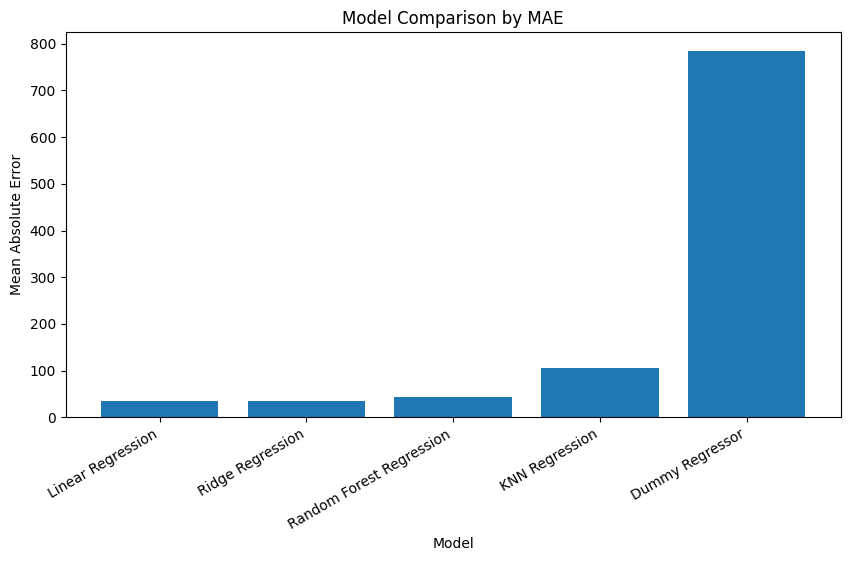

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=30, ha="right")
plt.show()

**Random Forest Prediction Accuracy**

The actual-versus-predicted plot shows that the Random Forest model performs well for most observations, with points closely following the diagonal reference line. However, **the model underpredicts very high-rent ZIP-code-month observations**, as shown by the **flattened prediction pattern** at the top-right of the graph. This helps explain why Random Forest has a higher RMSE than Linear Regression, despite still achieving a strong overall R².

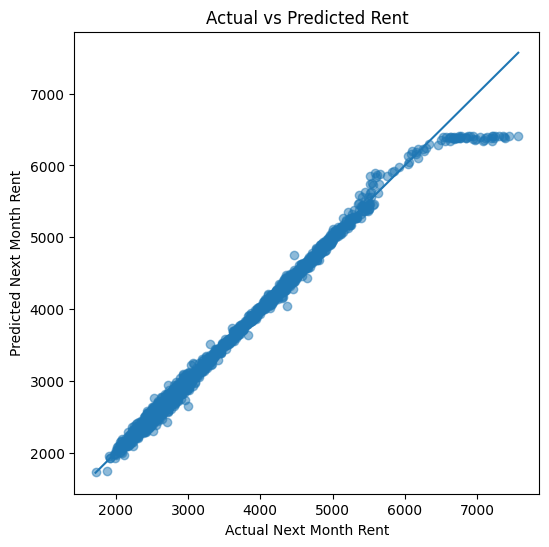

In [ ]:
best_pred = y_pred_rf

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Actual vs Predicted Rent")
plt.xlabel("Actual Next Month Rent")
plt.ylabel("Predicted Next Month Rent")
plt.show()

## V. Classification Model

### 1. Create classification target

    1 = ZIP-code-month is predicted to be high-rent next month
    0 = ZIP-code-month is predicted to be lower-rent next month

In [ ]:
# Create cutoff using the training period only to avoid data leakage
train_cutoff = model_df_final.loc[
    model_df_final["date"] < "2024-01-01",
    "target_next_month_rent"
].median()

print("High-rent cutoff:", train_cutoff)

# Create binary classification target
model_df_final["high_rent_next_month"] = (
    model_df_final["target_next_month_rent"] >= train_cutoff
).astype(int)

model_df_final["high_rent_next_month"].value_counts()

High-rent cutoff: 2651.898315946749


,count
high_rent_next_month,
1,6070
0,4779


### 2. Define X and y for classification

In [ ]:
features = [
    "zori_rent",
    "rent_lag_1",
    "rent_lag_2",
    "rent_lag_3",
    "rent_lag_12",
    "rent_growth_1m",
    "rent_growth_12m",
    "year",
    "month",
    "quarter",
    "borough",
    "is_lic"
]

target_class = "high_rent_next_month"

X_class = model_df_final[features].copy()
y_class = model_df_final[target_class].copy()

### 3. Time-based train-test split

In [ ]:
split_date = "2024-01-01"

train_mask = model_df_final["date"] < split_date
test_mask = model_df_final["date"] >= split_date

X_train_class = X_class[train_mask]
X_test_class = X_class[test_mask]

y_train_class = y_class[train_mask]
y_test_class = y_class[test_mask]

print("Training rows:", X_train_class.shape[0])
print("Testing rows:", X_test_class.shape[0])

print("Train class balance:")
print(y_train_class.value_counts(normalize=True))

print("Test class balance:")
print(y_test_class.value_counts(normalize=True))

Training rows: 7860
Testing rows: 2989
Train class balance:
high_rent_next_month
1    0.5
0    0.5
Name: proportion, dtype: float64
Test class balance:
high_rent_next_month
1    0.715959
0    0.284041
Name: proportion, dtype: float64


### 4. Build preprocessing pipeline

In [ ]:
numeric_features = [
    "zori_rent",
    "rent_lag_1",
    "rent_lag_2",
    "rent_lag_3",
    "rent_lag_12",
    "rent_growth_1m",
    "rent_growth_12m",
    "year",
    "month",
    "quarter",
    "is_lic"
]

categorical_features = ["borough"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

 ### 5. Logistic Regression classification

 Logistic Regression estimates whether next month’s rent will be above the high-rent cutoff. It is useful because it gives an interpretable classification model.

 Logistic Regression performs best in the classification task, with an **accuracy of 96.8%** and an F1 score of 0.977. The confusion matrix shows that **the model correctly identifies most high-rent ZIP-code-month observations**, with only 61 false negatives out of 2,140 actual high-rent cases.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

logistic_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_clf.fit(X_train_class, y_train_class)

y_pred_logistic = logistic_clf.predict(X_test_class)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test_class, y_pred_logistic))
print("Precision:", precision_score(y_test_class, y_pred_logistic))
print("Recall:", recall_score(y_test_class, y_pred_logistic))
print("F1:", f1_score(y_test_class, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_logistic))

Logistic Regression Results
Accuracy: 0.9678822348611575
Precision: 0.9834437086092715
Recall: 0.9714953271028037
F1: 0.9774330042313117

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       849
           1       0.98      0.97      0.98      2140

    accuracy                           0.97      2989
   macro avg       0.96      0.97      0.96      2989
weighted avg       0.97      0.97      0.97      2989



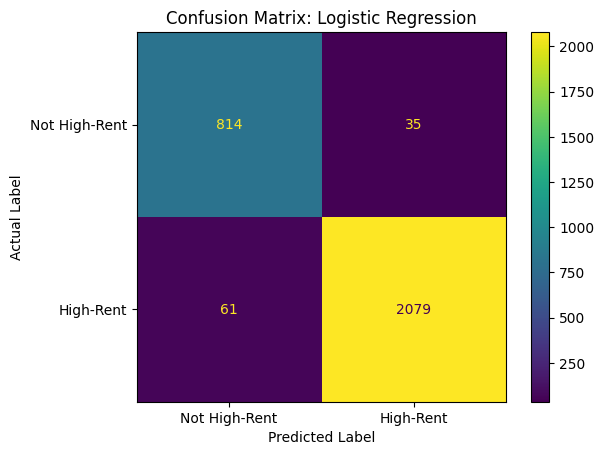

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Create confusion matrix for Logistic Regression
cm_logistic = confusion_matrix(y_test_class, y_pred_logistic)

# Plot confusion matrix
disp_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not High-Rent", "High-Rent"]

)

disp_logistic.plot(values_format="d")
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

### 6. KNN Classification

KNN Classification predicts whether a ZIP-code-month is high-rent by looking at similar observations in the training data.

KNN Classification performs reasonably well, with an **accuracy of 89.5%**, but it produces **more false negatives and has a lower recall**.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_clf.fit(X_train_class, y_train_class)

y_pred_knn_class = knn_clf.predict(X_test_class)

print("KNN Classification Results")
print("Accuracy:", accuracy_score(y_test_class, y_pred_knn_class))
print("Precision:", precision_score(y_test_class, y_pred_knn_class))
print("Recall:", recall_score(y_test_class, y_pred_knn_class))
print("F1:", f1_score(y_test_class, y_pred_knn_class))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_knn_class))

KNN Classification Results
Accuracy: 0.8946135831381733
Precision: 0.9672299027137736
Recall: 0.8827102803738318
F1: 0.9230393354507697

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.92      0.83       849
           1       0.97      0.88      0.92      2140

    accuracy                           0.89      2989
   macro avg       0.86      0.90      0.88      2989
weighted avg       0.91      0.89      0.90      2989



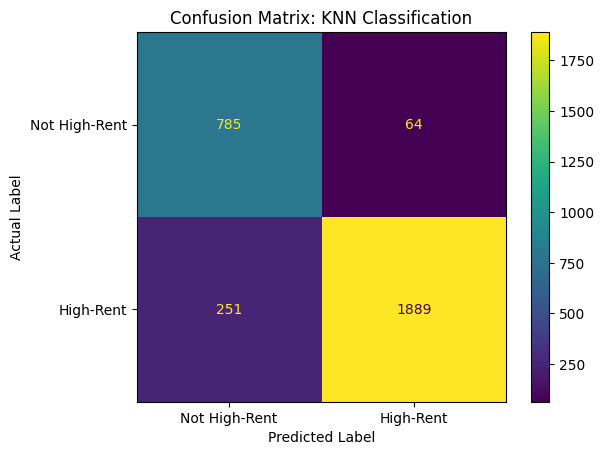

In [ ]:
# Create confusion matrix for KNN Classification
cm_knn = confusion_matrix(y_test_class, y_pred_knn_class)

# Plot confusion matrix
disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["Not High-Rent", "High-Rent"]
)

disp_knn.plot(values_format="d")

plt.title("Confusion Matrix: KNN Classification")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

###  7. Classification comparison table

The result suggests that **the high-rent classification boundary is relatively linear** and can be captured effectively by **Logistic Regression** using current rent, lagged rent, rent growth, time, and borough features.

In [ ]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN Classification"
    ],
    "Accuracy": [
        accuracy_score(y_test_class, y_pred_logistic),
        accuracy_score(y_test_class, y_pred_knn_class)
    ],
    "Precision": [
        precision_score(y_test_class, y_pred_logistic),
        precision_score(y_test_class, y_pred_knn_class)
    ],
    "Recall": [
        recall_score(y_test_class, y_pred_logistic),
        recall_score(y_test_class, y_pred_knn_class)
    ],
    "F1": [
        f1_score(y_test_class, y_pred_logistic),
        f1_score(y_test_class, y_pred_knn_class)
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.967882,0.983444,0.971495,0.977433
1,KNN Classification,0.894614,0.967230,0.882710,0.923039
